# Analisis Pengaruh Manajemen Nutrisi Presisi Berbasis Sensor terhadap Produktivitas TBS Kelapa Sawit

**Projek Probabilitas dan Statistika - Kelompok 3 (3 TI F), Politeknik Caltex Riau**

Anggota: Intan Lestari W (2455301223), M. Narum Bella (2455301225), Mirna (2455301226),
Raihan Ahmada Siahaan (2455301234)

Sumber data: Wiratmoko, Nugroho, & Sutiarso (2026), Zenodo,
https://doi.org/10.5281/zenodo.22703312 (CC BY 4.0)

Rumusan masalah:
1. Bagaimana gambaran produktivitas TBS, umur tanaman, dan defisit air klimatik pada 240 blok
   kebun sawit tahun 2019-2025?
2. Apakah terdapat perbedaan rata-rata produktivitas TBS yang signifikan antara blok pemupukan
   presisi berbasis sensor dan blok pemupukan seragam pada tahun 2024-2025?
3. Seberapa besar pengaruh umur tanaman dan defisit air klimatik terhadap produktivitas TBS?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NarumBella-TIG/ProbStat-Kelompok3/blob/main/analisis_probstat_kelompok3.ipynb)

## 0. Persiapan library

In [1]:
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.dpi"] = 110

ALPHA = 0.05            # taraf signifikansi untuk semua uji
OUT = "output"          # folder hasil grafik dan tabel
os.makedirs(OUT, exist_ok=True)


def simpan(fig, nama):
    """Simpan grafik ke folder output lalu tampilkan."""
    fig.tight_layout()
    fig.savefig(os.path.join(OUT, nama), dpi=150)
    plt.show()

## 1. Membaca dan memeriksa data

Data dibaca dari folder `data/`. Kalau file tidak ada (misalnya saat dijalankan di Google Colab),
file diunduh otomatis dari repository GitHub kelompok.

In [2]:
FILE = "data/3TIF_03_ProduktivitasTBSSawit.xlsx"
URL = ("https://raw.githubusercontent.com/NarumBella-TIG/ProbStat-Kelompok3/main/"
       "data/3TIF_03_ProduktivitasTBSSawit.xlsx")

if not os.path.exists(FILE):
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(URL, FILE)

df = pd.read_excel(FILE, sheet_name="Dataset")
print("Ukuran data:", df.shape[0], "baris x", df.shape[1], "kolom")
df.head()

Ukuran data: 1676 baris x 77 kolom


,estate_id,division_id,block_id,matched_pair_id,assigned_group,management_system,observation_year,harvest_start_date,harvest_end_date,cultivar,...,cpo_yield_t_ha,n_partial_factor_productivity_kg_kg,k_partial_factor_productivity_kg_kg,total_fertilizer_input_kg_t_ffb,ffb_price_usd_t,fertilizer_cost_usd_ha,field_operation_cost_usd_ha,direct_energy_input_mj_ha,ghg_intensity_kg_co2e_t_ffb,gross_margin_usd_ha
0,EST-A,EST-A-D1,EST-A-B001,EST-A-P01,control_arm,uniform_standard,2019,2019-01-01,2019-12-31,LONSUM,...,5.417820,160.151324,114.620939,18.248031,158.24,476.47,764.65,8044,66.738583,2778.1760
1,EST-A,EST-A-D1,EST-A-B001,EST-A-P01,control_arm,uniform_standard,2020,2020-01-01,2020-12-31,LONSUM,...,4.648332,137.547893,108.897877,20.232591,159.70,451.48,751.93,7865,76.642433,2236.5280
2,EST-A,EST-A-D1,EST-A-B001,EST-A-P01,control_arm,uniform_standard,2021,2021-01-01,2021-12-31,LONSUM,...,5.280696,182.963493,110.649351,17.498826,158.66,454.82,776.41,7871,61.789750,2824.1196
3,EST-A,EST-A-D1,EST-A-B001,EST-A-P01,control_arm,uniform_standard,2022,2022-01-01,2022-12-31,LONSUM,...,5.050908,174.784483,112.119816,17.829429,171.86,447.32,703.41,7751,64.026387,3030.6238
4,EST-A,EST-A-D1,EST-A-B001,EST-A-P01,control_arm,uniform_standard,2024,2024-01-01,2024-12-31,LONSUM,...,5.563680,173.462783,121.929026,16.767164,167.81,460.75,797.58,7969,61.899925,3238.9780


In [3]:
# Unit observasi = satu blok kebun pada satu tahun,
# jadi kombinasi block_id + observation_year harus unik
duplikat = df.duplicated(["block_id", "observation_year"]).sum()
print("Baris duplikat (blok + tahun):", duplikat)
print("Jumlah blok:", df["block_id"].nunique(),
      "| jumlah pasangan:", df["matched_pair_id"].nunique())
print("Tahun pengamatan:", sorted(df["observation_year"].unique().tolist()))

# Missing value per kolom (hanya kolom yang ada data kosongnya)
missing = df.isna().sum()
print("\nMissing value:")
print(missing[missing > 0])

Baris duplikat (blok + tahun): 0
Jumlah blok: 240 | jumlah pasangan: 120
Tahun pengamatan: [2019, 2020, 2021, 2022, 2023, 2024, 2025]

Missing value:
uav_ndvi_mean         38
uav_ndre_mean         38
canopy_temp_c_mean    38
canopy_cover_pct      38
dtype: int64


In [4]:
# Tiga variabel utama dan satu variabel pengelompok
Y = "ffb_yield_t_ha"                 # produktivitas TBS (ton/ha/tahun)
UMUR = "palm_age_yr"                 # umur tanaman (tahun)
DEFISIT = "climatic_water_deficit_mm"  # defisit air klimatik (mm/tahun)
SISTEM = "management_system"         # sistem pemupukan

UTAMA = [Y, UMUR, DEFISIT]
LABEL = {Y: "Produktivitas TBS (ton/ha/tahun)",
         UMUR: "Umur tanaman (tahun)",
         DEFISIT: "Defisit air klimatik (mm/tahun)"}
NAMA_SISTEM = {"sensor_guided_variable_rate": "Presisi berbasis sensor",
               "uniform_standard": "Seragam (standar)"}

print(df[UTAMA].dtypes)
print("Missing pada variabel utama:", int(df[UTAMA].isna().sum().sum()))

ffb_yield_t_ha               float64
palm_age_yr                    int64
climatic_water_deficit_mm      int64
dtype: object
Missing pada variabel utama: 0


## 2. Rumusan Masalah 1: Statistika deskriptif

In [5]:
def ringkasan(data):
    """Statistik deskriptif lengkap untuk satu kolom angka."""
    q1, q3 = data.quantile([0.25, 0.75])
    return pd.Series({
        "n": data.count(),
        "rata-rata": data.mean(),
        "median": data.median(),
        "modus": data.mode().iloc[0],
        "simpangan baku": data.std(),
        "varians": data.var(),
        "minimum": data.min(),
        "Q1": q1,
        "Q3": q3,
        "maksimum": data.max(),
        "jangkauan": data.max() - data.min(),
        "IQR": q3 - q1,
        "koef. variasi (%)": data.std() / data.mean() * 100,
        "skewness": stats.skew(data),
        "kurtosis": stats.kurtosis(data),
    })


tabel_deskriptif = pd.DataFrame({LABEL[k]: ringkasan(df[k]) for k in UTAMA}).round(2)
tabel_deskriptif.to_csv(os.path.join(OUT, "tabel1_deskriptif.csv"))
tabel_deskriptif

,Produktivitas TBS (ton/ha/tahun),Umur tanaman (tahun),Defisit air klimatik (mm/tahun)
n,1676.00,1676.00,1676.00
rata-rata,24.15,14.40,84.37
median,24.42,14.00,68.00
modus,27.34,14.00,46.00
simpangan baku,3.23,4.11,58.19
varians,10.44,16.92,3386.57
minimum,11.65,5.00,0.00
Q1,22.25,11.00,44.00
Q3,26.51,18.00,104.25
maksimum,32.34,24.00,271.00


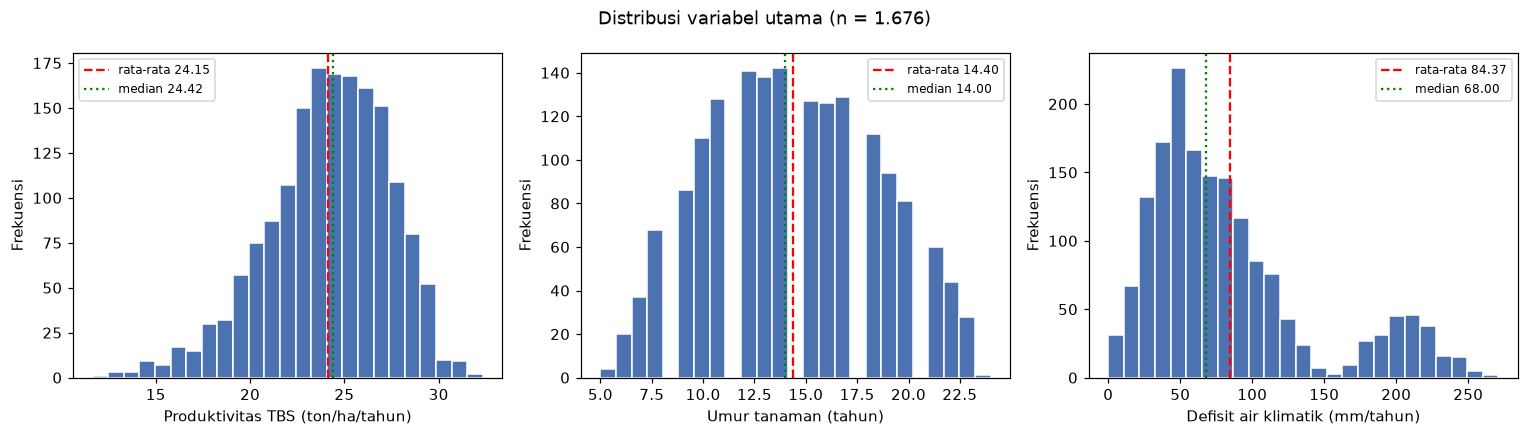

In [6]:
# Histogram ketiga variabel utama
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for i, k in enumerate(UTAMA):
    ax[i].hist(df[k], bins=25, color="#4C72B0", edgecolor="white")
    ax[i].axvline(df[k].mean(), color="red", linestyle="--", label=f"rata-rata {df[k].mean():.2f}")
    ax[i].axvline(df[k].median(), color="green", linestyle=":",
                  label=f"median {df[k].median():.2f}")
    ax[i].set_xlabel(LABEL[k])
    ax[i].set_ylabel("Frekuensi")
    ax[i].legend(fontsize=8)
fig.suptitle("Distribusi variabel utama (n = 1.676)")
simpan(fig, "gambar1_histogram_variabel_utama.png")

                  Blok kontrol  Blok presisi  Selisih
observation_year                                     
2019                     24.51         24.34    -0.17
2020                     22.78         22.80     0.02
2021                     25.36         25.54     0.18
2022                     24.39         24.25    -0.14
2023                     24.82         24.96     0.14
2024                     22.16         23.43     1.27
2025                     23.89         24.95     1.06


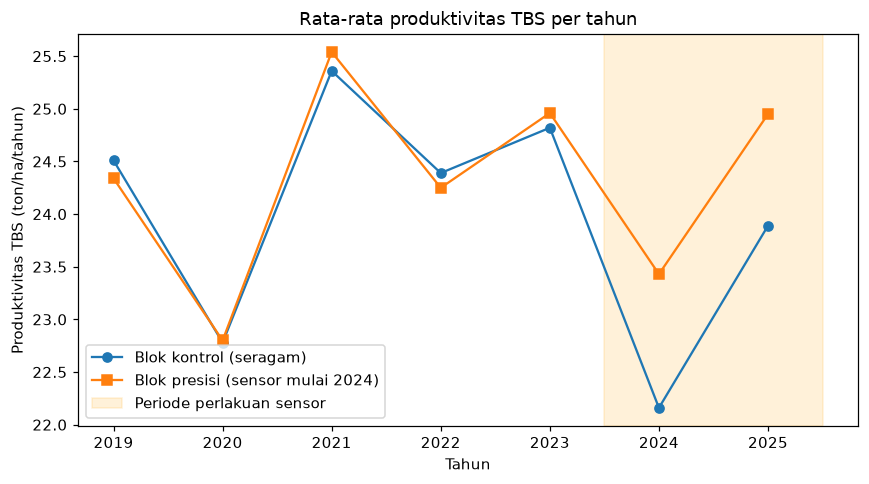

In [7]:
# Rata-rata produktivitas per tahun untuk kedua kelompok blok.
# 2019-2023 semua blok masih dipupuk seragam; 2024-2025 blok precision_arm memakai sensor.
per_tahun = df.pivot_table(index="observation_year", columns="assigned_group",
                           values=Y, aggfunc="mean").round(2)
per_tahun.columns = ["Blok kontrol", "Blok presisi"]
per_tahun["Selisih"] = (per_tahun["Blok presisi"] - per_tahun["Blok kontrol"]).round(2)
per_tahun.to_csv(os.path.join(OUT, "tabel2_rata_rata_per_tahun.csv"))
print(per_tahun)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(per_tahun.index, per_tahun["Blok kontrol"], marker="o", label="Blok kontrol (seragam)")
ax.plot(per_tahun.index, per_tahun["Blok presisi"], marker="s",
        label="Blok presisi (sensor mulai 2024)")
ax.axvspan(2023.5, 2025.5, color="orange", alpha=0.15, label="Periode perlakuan sensor")
ax.set_xlabel("Tahun")
ax.set_ylabel(LABEL[Y])
ax.set_title("Rata-rata produktivitas TBS per tahun")
ax.legend()
simpan(fig, "gambar2_tren_per_tahun.png")

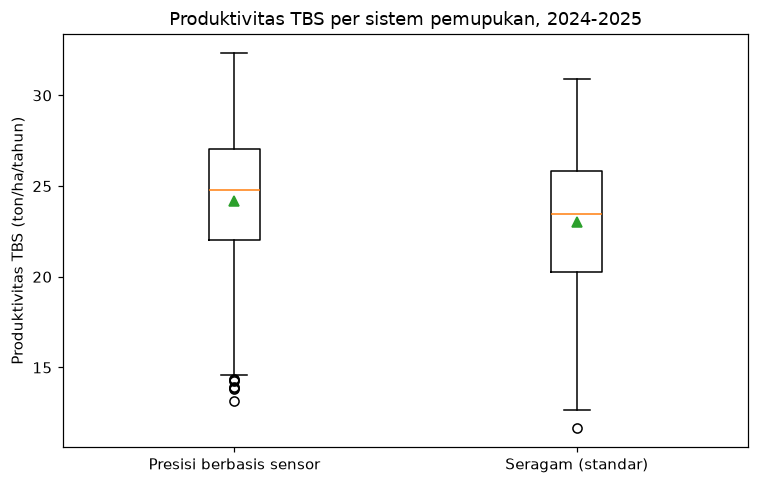

,n,rata-rata,median,modus,simpangan baku,varians,minimum,Q1,Q3,maksimum,jangkauan,IQR,koef. variasi (%),skewness,kurtosis
Presisi berbasis sensor,240.0,24.19,24.79,25.41,4.04,16.30,13.18,22.04,27.04,32.34,19.16,5.00,16.69,-0.65,-0.02
Seragam (standar),240.0,23.03,23.46,19.37,3.85,14.84,11.65,20.28,25.84,30.91,19.26,5.56,16.73,-0.48,-0.27


In [8]:
# Boxplot produktivitas per sistem pemupukan pada periode perlakuan (2024-2025)
perlakuan = df[df["observation_year"] >= 2024]
kelompok = [perlakuan.loc[perlakuan[SISTEM] == s, Y] for s in NAMA_SISTEM]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot(kelompok, tick_labels=list(NAMA_SISTEM.values()), showmeans=True)
ax.set_ylabel(LABEL[Y])
ax.set_title("Produktivitas TBS per sistem pemupukan, 2024-2025")
simpan(fig, "gambar3_boxplot_sistem_pemupukan.png")

tabel_sistem = perlakuan.groupby(SISTEM)[Y].apply(ringkasan).unstack().round(2)
tabel_sistem.index = [NAMA_SISTEM[i] for i in tabel_sistem.index]
tabel_sistem.to_csv(os.path.join(OUT, "tabel3_deskriptif_per_sistem.csv"))
tabel_sistem

## 3. Distribusi probabilitas produktivitas TBS

Produktivitas TBS adalah variabel kontinu, sehingga didekati dengan distribusi normal.
Kecocokannya diperiksa dengan Q-Q plot, lalu dipakai untuk menghitung peluang.

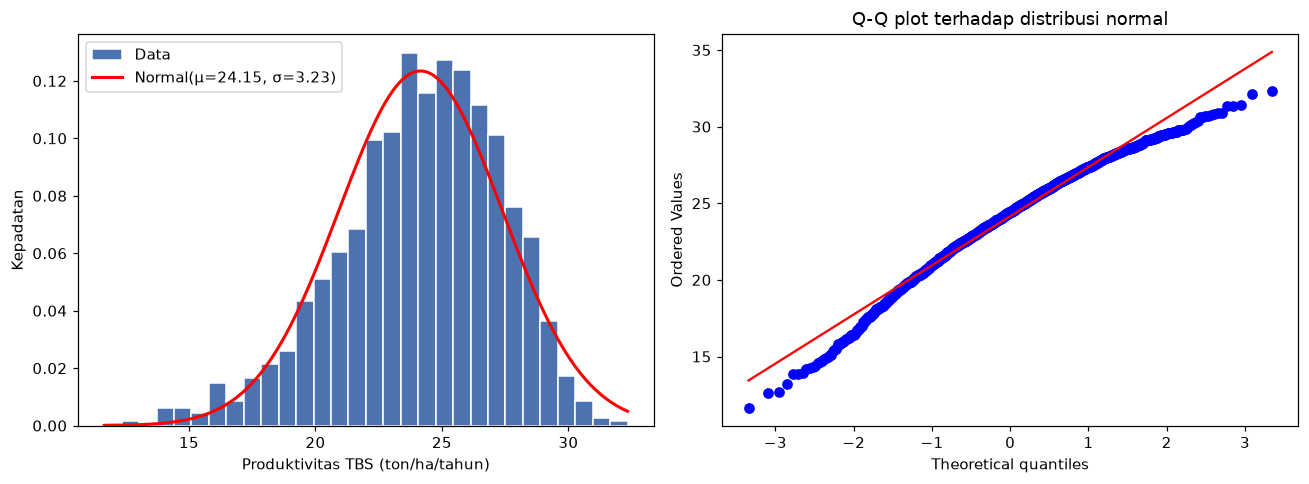

In [9]:
mu, sigma = df[Y].mean(), df[Y].std()
x = np.linspace(df[Y].min(), df[Y].max(), 200)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].hist(df[Y], bins=30, density=True, color="#4C72B0", edgecolor="white", label="Data")
ax[0].plot(x, stats.norm.pdf(x, mu, sigma), "r-", lw=2, label=f"Normal(μ={mu:.2f}, σ={sigma:.2f})")
ax[0].set_xlabel(LABEL[Y])
ax[0].set_ylabel("Kepadatan")
ax[0].legend()
stats.probplot(df[Y], dist="norm", plot=ax[1])
ax[1].set_title("Q-Q plot terhadap distribusi normal")
simpan(fig, "gambar4_distribusi_normal_tbs.png")

In [10]:
# Peluang dihitung dua cara: dari model normal dan dari proporsi data sebenarnya (empiris)
batas_atas, batas_bawah = 28, 20
peluang = pd.DataFrame({
    "Model normal": [1 - stats.norm.cdf(batas_atas, mu, sigma),
                     stats.norm.cdf(batas_bawah, mu, sigma),
                     stats.norm.cdf(batas_atas, mu, sigma)
                     - stats.norm.cdf(batas_bawah, mu, sigma)],
    "Empiris (data)": [(df[Y] > batas_atas).mean(),
                       (df[Y] < batas_bawah).mean(),
                       df[Y].between(batas_bawah, batas_atas).mean()],
}, index=[f"P(TBS > {batas_atas})", f"P(TBS < {batas_bawah})",
          f"P({batas_bawah} ≤ TBS ≤ {batas_atas})"]).round(4)
peluang.to_csv(os.path.join(OUT, "tabel4_peluang_normal.csv"))
print("Skewness:", round(stats.skew(df[Y]), 3), "| Kurtosis:", round(stats.kurtosis(df[Y]), 3))
peluang

Skewness: -0.564 | Kurtosis: 0.325


,Model normal,Empiris (data)
P(TBS > 28),0.1170,0.1056
P(TBS < 20),0.0993,0.1068
P(20 ≤ TBS ≤ 28),0.7837,0.7876


## 4. Rumusan Masalah 2: Uji beda produktivitas blok presisi vs blok seragam

Setiap blok presisi sudah dipasangkan dengan satu blok kontrol (120 pasangan),
sehingga uji yang dipakai
adalah **uji t sampel berpasangan** pada periode perlakuan 2024-2025.

- H0: rata-rata selisih produktivitas (presisi - seragam) = 0
- H1: rata-rata selisih produktivitas ≠ 0
- α = 0,05

In [11]:
def data_berpasangan(data):
    """Satu baris per pasangan per tahun, kolom = produktivitas blok presisi dan blok kontrol."""
    p = data.pivot_table(index=["matched_pair_id", "observation_year"],
                         columns="assigned_group", values=Y).dropna()
    return p["precision_arm"], p["control_arm"]


presisi, kontrol = data_berpasangan(perlakuan)
selisih = presisi - kontrol
n = len(selisih)
print("Jumlah pasangan-tahun:", n)
print(f"Rata-rata selisih: {selisih.mean():.3f} ton/ha | "
      f"simpangan baku selisih: {selisih.std():.3f}")
print("Pasangan yang blok presisinya lebih tinggi:", int((selisih > 0).sum()), "dari", n)

Jumlah pasangan-tahun: 240
Rata-rata selisih: 1.164 ton/ha | simpangan baku selisih: 1.924
Pasangan yang blok presisinya lebih tinggi: 169 dari 240


Shapiro-Wilk selisih: W = 0.9956, p = 0.7368
Kesimpulan: selisih berdistribusi normal


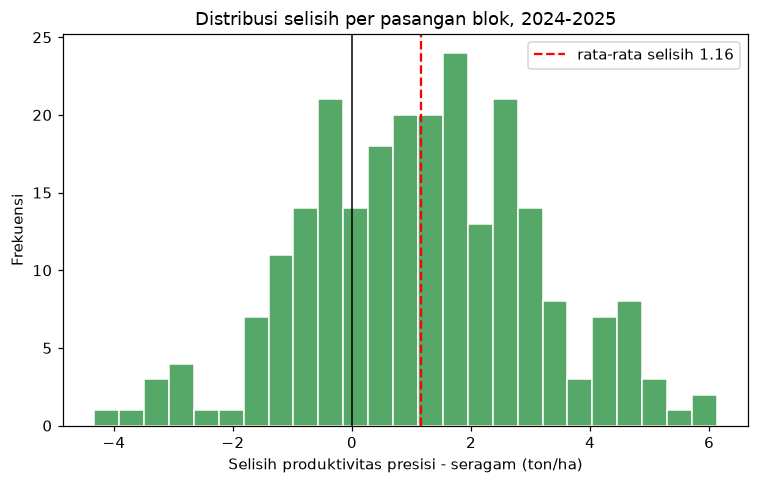

In [12]:
# Syarat uji t berpasangan: selisih berdistribusi normal (uji Shapiro-Wilk)
sw = stats.shapiro(selisih)
print(f"Shapiro-Wilk selisih: W = {sw.statistic:.4f}, p = {sw.pvalue:.4f}")
print("Kesimpulan:",
      "selisih berdistribusi normal" if sw.pvalue > ALPHA else "selisih tidak normal")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(selisih, bins=25, color="#55A868", edgecolor="white")
ax.axvline(0, color="black", lw=1)
ax.axvline(selisih.mean(), color="red", linestyle="--",
           label=f"rata-rata selisih {selisih.mean():.2f}")
ax.set_xlabel("Selisih produktivitas presisi - seragam (ton/ha)")
ax.set_ylabel("Frekuensi")
ax.set_title("Distribusi selisih per pasangan blok, 2024-2025")
ax.legend()
simpan(fig, "gambar5_histogram_selisih_pasangan.png")

In [13]:
uji_t = stats.ttest_rel(presisi, kontrol)
ci = stats.t.interval(1 - ALPHA, df=n - 1, loc=selisih.mean(), scale=stats.sem(selisih))
cohen_dz = selisih.mean() / selisih.std()
wilcoxon = stats.wilcoxon(selisih)  # uji nonparametrik sebagai pembanding

print(f"Uji t berpasangan: t({n - 1}) = {uji_t.statistic:.3f}, p = {uji_t.pvalue:.3e}")
print(f"Interval kepercayaan 95% rata-rata selisih: {ci[0]:.3f} sampai {ci[1]:.3f} ton/ha")
print(f"Ukuran efek Cohen's dz: {cohen_dz:.3f}")
print(f"Wilcoxon signed-rank: W = {wilcoxon.statistic:.1f}, p = {wilcoxon.pvalue:.3e}")
print("Keputusan:",
      "H0 ditolak, ada perbedaan signifikan" if uji_t.pvalue < ALPHA else "H0 diterima")

Uji t berpasangan: t(239) = 9.374, p = 5.534e-18
Interval kepercayaan 95% rata-rata selisih: 0.920 sampai 1.409 ton/ha
Ukuran efek Cohen's dz: 0.605
Wilcoxon signed-rank: W = 5612.5, p = 2.078e-16
Keputusan: H0 ditolak, ada perbedaan signifikan


In [14]:
# Pemeriksaan pembanding: sebelum perlakuan (2019-2023) kedua kelompok seharusnya tidak berbeda.
# Uji yang sama juga diulang per tahun.
hasil_uji = []
periode = {"2019-2023 (sebelum)": df[df["observation_year"] <= 2023],
           "2024-2025 (perlakuan)": perlakuan,
           "2024": df[df["observation_year"] == 2024],
           "2025": df[df["observation_year"] == 2025]}
for nama, data in periode.items():
    a, b = data_berpasangan(data)
    t = stats.ttest_rel(a, b)
    hasil_uji.append({"Periode": nama, "n pasangan": len(a), "rata-rata presisi": a.mean(),
                      "rata-rata kontrol": b.mean(), "rata-rata selisih": (a - b).mean(),
                      "t": t.statistic, "p-value": t.pvalue,
                      "keputusan": "signifikan" if t.pvalue < ALPHA else "tidak signifikan"})
tabel_uji = pd.DataFrame(hasil_uji).round(4)
tabel_uji.to_csv(os.path.join(OUT, "tabel5_uji_t_berpasangan.csv"), index=False)
tabel_uji

,Periode,n pasangan,rata-rata presisi,rata-rata kontrol,rata-rata selisih,t,p-value,keputusan
0,2019-2023 (sebelum),596,24.3727,24.3676,0.0051,0.0679,0.9459,tidak signifikan
1,2024-2025 (perlakuan),240,24.1912,23.0270,1.1642,9.3741,0.0000,signifikan
2,2024,120,23.4338,22.1597,1.2741,7.0106,0.0000,signifikan
3,2025,120,24.9487,23.8942,1.0544,6.2208,0.0000,signifikan


## 5. Rumusan Masalah 3: Pengaruh umur tanaman dan defisit air terhadap produktivitas

Langkah: korelasi Pearson, lalu regresi linear berganda. Karena hubungan umur dengan produktivitas
diduga melengkung, dibuat dua model:

- Model 1: TBS = b0 + b1·umur + b2·defisit
- Model 2: TBS = b0 + b1·umur + b2·umur² + b3·defisit

In [15]:
hasil_korelasi = []
for k in [UMUR, DEFISIT]:
    r, p = stats.pearsonr(df[k], df[Y])
    hasil_korelasi.append({"Variabel": LABEL[k], "r Pearson": r, "p-value": p,
                           "keputusan": "signifikan" if p < ALPHA else "tidak signifikan"})
tabel_korelasi = pd.DataFrame(hasil_korelasi).round(4)
tabel_korelasi.to_csv(os.path.join(OUT, "tabel6_korelasi.csv"), index=False)
tabel_korelasi

,Variabel,r Pearson,p-value,keputusan
0,Umur tanaman (tahun),-0.2297,0.0,signifikan
1,Defisit air klimatik (mm/tahun),-0.1424,0.0,signifikan


In [16]:
# Rata-rata produktivitas per kelompok umur, untuk melihat bentuk hubungannya
df["kelompok_umur"] = pd.cut(df[UMUR], bins=[4, 8, 12, 16, 20, 24],
                             labels=["5-8", "9-12", "13-16", "17-20", "21-24"])
tabel_umur = df.groupby("kelompok_umur", observed=True)[Y].agg(["count", "mean", "std"]).round(2)
tabel_umur.columns = ["n", "rata-rata TBS", "simpangan baku"]
tabel_umur.to_csv(os.path.join(OUT, "tabel7_tbs_per_kelompok_umur.csv"))
tabel_umur

,n,rata-rata TBS,simpangan baku
kelompok_umur,,,
5-8,129,21.06,2.54
9-12,465,24.97,2.35
13-16,533,26.09,2.22
17-20,416,23.41,2.63
21-24,133,18.84,2.85


In [17]:
model1 = smf.ols(f"{Y} ~ {UMUR} + {DEFISIT}", data=df).fit()
model2 = smf.ols(f"{Y} ~ {UMUR} + I({UMUR}**2) + {DEFISIT}", data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:         ffb_yield_t_ha   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     68.36
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           2.91e-29
Time:                        11:11:23   Log-Likelihood:                -4277.7
No. Observations:                1676   AIC:                             8561.
Df Residuals:                    1673   BIC:                             8578.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [18]:
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:         ffb_yield_t_ha   R-squared:                       0.545
Model:                            OLS   Adj. R-squared:                  0.544
Method:                 Least Squares   F-statistic:                     667.2
Date:                Sat, 03 Oct 2026   Prob (F-statistic):          4.00e-285
Time:                        11:11:23   Log-Likelihood:                -3684.0
No. Observations:                1676   AIC:                             7376.
Df Residuals:                    1672   BIC:                             7398.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [19]:
perbandingan = pd.DataFrame({
    "Model 1 (linear)": [model1.rsquared, model1.rsquared_adj, model1.fvalue,
                         model1.f_pvalue, model1.aic],
    "Model 2 (+ umur²)": [model2.rsquared, model2.rsquared_adj, model2.fvalue,
                          model2.f_pvalue, model2.aic],
}, index=["R²", "R² disesuaikan", "F", "p-value F", "AIC"]).round(4)
perbandingan.to_csv(os.path.join(OUT, "tabel8_perbandingan_model.csv"))

koef = pd.DataFrame({"koefisien": model2.params, "p-value": model2.pvalues}).round(5)
koef.to_csv(os.path.join(OUT, "tabel9_koefisien_model2.csv"))
umur_puncak = -model2.params[UMUR] / (2 * model2.params[f"I({UMUR} ** 2)"])
print(f"Umur dengan produktivitas tertinggi menurut Model 2: {umur_puncak:.1f} tahun")
print(koef)
perbandingan

Umur dengan produktivitas tertinggi menurut Model 2: 13.8 tahun
                           koefisien  p-value
Intercept                    4.51161      0.0
palm_age_yr                  3.27914      0.0
I(palm_age_yr ** 2)         -0.11908      0.0
climatic_water_deficit_mm   -0.01033      0.0


,Model 1 (linear),Model 2 (+ umur²)
R²,0.0755,0.5448
R² disesuaikan,0.0744,0.5440
F,68.3580,667.1631
p-value F,0.0000,0.0000
AIC,8561.4825,7375.9193


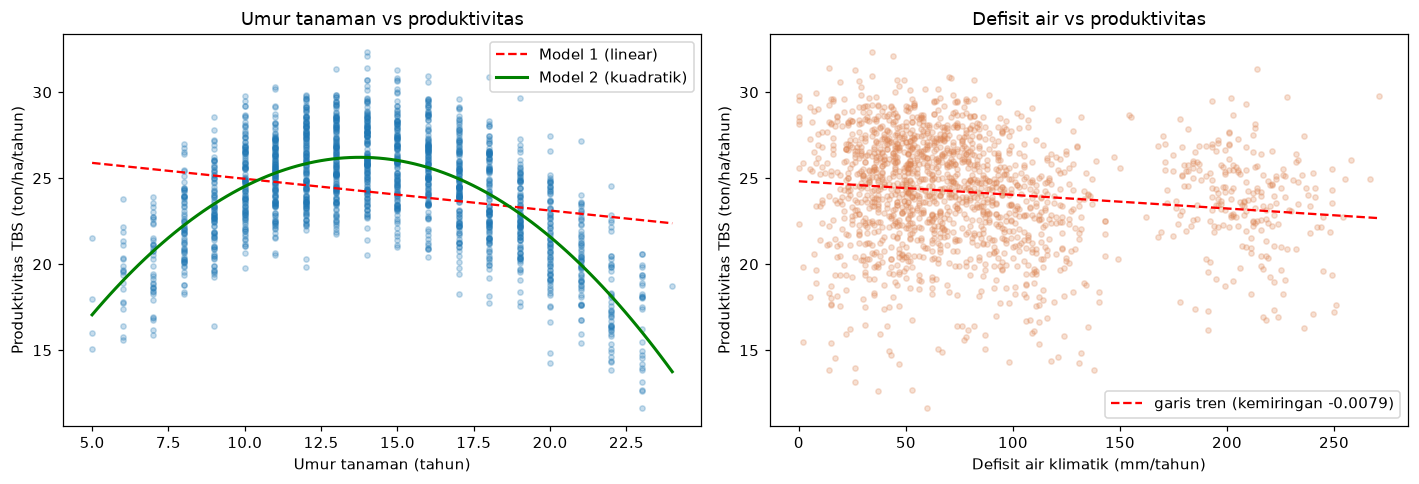

In [20]:
# Scatter plot dan garis/kurva hasil regresi
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].scatter(df[UMUR], df[Y], alpha=0.25, s=12)
u = np.linspace(df[UMUR].min(), df[UMUR].max(), 100)
d_rata = df[DEFISIT].mean()
ax[0].plot(u, model1.predict(pd.DataFrame({UMUR: u, DEFISIT: d_rata})), "r--",
           label="Model 1 (linear)")
ax[0].plot(u, model2.predict(pd.DataFrame({UMUR: u, DEFISIT: d_rata})), "g-", lw=2,
           label="Model 2 (kuadratik)")
ax[0].set_xlabel(LABEL[UMUR])
ax[0].set_ylabel(LABEL[Y])
ax[0].set_title("Umur tanaman vs produktivitas")
ax[0].legend()

ax[1].scatter(df[DEFISIT], df[Y], alpha=0.25, s=12, color="#DD8452")
m, b = np.polyfit(df[DEFISIT], df[Y], 1)
dd = np.linspace(df[DEFISIT].min(), df[DEFISIT].max(), 100)
ax[1].plot(dd, m * dd + b, "r--", label=f"garis tren (kemiringan {m:.4f})")
ax[1].set_xlabel(LABEL[DEFISIT])
ax[1].set_ylabel(LABEL[Y])
ax[1].set_title("Defisit air vs produktivitas")
ax[1].legend()
simpan(fig, "gambar6_scatter_regresi.png")

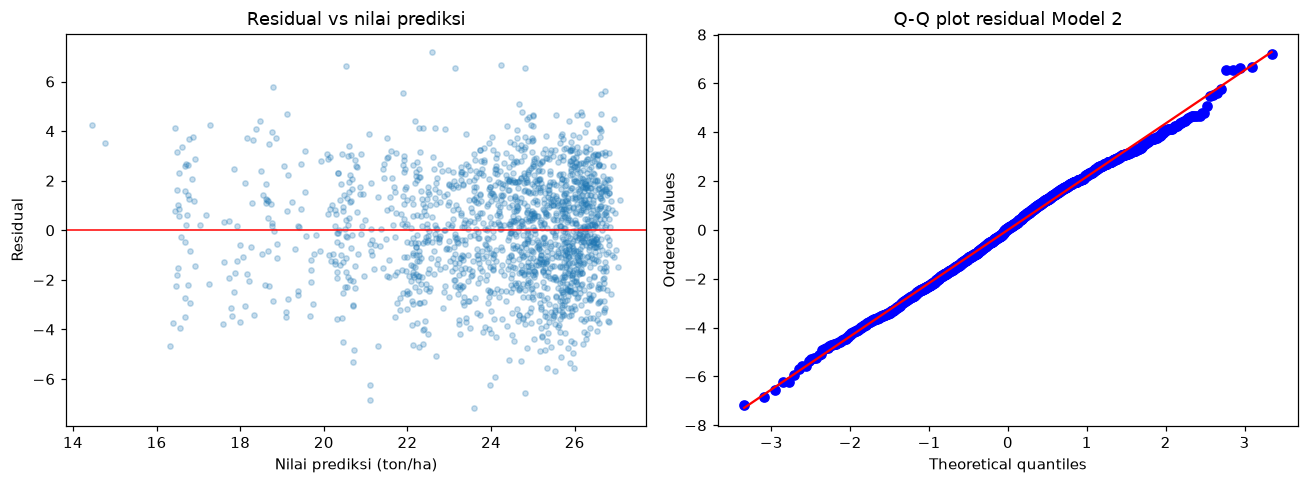

In [21]:
# Pemeriksaan asumsi regresi Model 2: sisaan (residual) menyebar acak dan mendekati normal
residual = model2.resid
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(model2.fittedvalues, residual, alpha=0.25, s=12)
ax[0].axhline(0, color="red", lw=1)
ax[0].set_xlabel("Nilai prediksi (ton/ha)")
ax[0].set_ylabel("Residual")
ax[0].set_title("Residual vs nilai prediksi")
stats.probplot(residual, dist="norm", plot=ax[1])
ax[1].set_title("Q-Q plot residual Model 2")
simpan(fig, "gambar7_asumsi_residual.png")

## 6. Ringkasan hasil

In [22]:
print("RINGKASAN HASIL ANALISIS")
print("=" * 60)
print(f"RM1  Rata-rata produktivitas TBS {df[Y].mean():.2f} ton/ha (sd {df[Y].std():.2f}), "
      f"rentang {df[Y].min():.2f}-{df[Y].max():.2f}")
print(f"     Rata-rata umur tanaman {df[UMUR].mean():.1f} tahun, "
      f"defisit air {df[DEFISIT].mean():.1f} mm/tahun")
print(f"RM2  Selisih rata-rata presisi - seragam (2024-2025): {selisih.mean():.2f} ton/ha, "
      f"t = {uji_t.statistic:.2f}, p = {uji_t.pvalue:.2e} -> "
      f"{'signifikan' if uji_t.pvalue < ALPHA else 'tidak signifikan'}")
sebelum = tabel_uji.iloc[0]
print(f"     Sebelum perlakuan (2019-2023): selisih {sebelum['rata-rata selisih']:.2f}, "
      f"p = {sebelum['p-value']:.3f} "
      f"-> {sebelum['keputusan']}")
print(f"RM3  Model 1 R² = {model1.rsquared:.3f}; Model 2 (dengan umur²) R² = {model2.rsquared:.3f}")
print(f"     Produktivitas tertinggi pada umur sekitar {umur_puncak:.1f} tahun; "
      f"koefisien defisit air = {model2.params[DEFISIT]:.4f} ton/ha per mm")
print(f"\nSemua grafik dan tabel tersimpan di folder '{OUT}/'")

RINGKASAN HASIL ANALISIS
RM1  Rata-rata produktivitas TBS 24.15 ton/ha (sd 3.23), rentang 11.65-32.34
     Rata-rata umur tanaman 14.4 tahun, defisit air 84.4 mm/tahun
RM2  Selisih rata-rata presisi - seragam (2024-2025): 1.16 ton/ha, t = 9.37, p = 5.53e-18 -> signifikan
     Sebelum perlakuan (2019-2023): selisih 0.01, p = 0.946 -> tidak signifikan
RM3  Model 1 R² = 0.076; Model 2 (dengan umur²) R² = 0.545
     Produktivitas tertinggi pada umur sekitar 13.8 tahun; koefisien defisit air = -0.0103 ton/ha per mm

Semua grafik dan tabel tersimpan di folder 'output/'
